# Urban Flow Analytics: AI-Driven Taxi Intelligence

## SLIIT Codefest Datathon 2026

### Urban Flow Analytics Data Challenge

This notebook presents the complete analytical and machine learning solution
developed for the Urban Flow Analytics Data Challenge.

The solution addresses five major analytical objectives:

1. Data quality assessment and anomaly handling
2. Base fare prediction
3. Trip duration / ETA prediction
4. Taxi demand forecasting for high-volume zones
5. Spatial hotspot and origin-destination flow analysis

The analysis uses taxi trip records covering April 2025 to March 2026 together
with the corresponding taxi-zone reference dataset.

The final notebook focuses on the validated results, modelling methodology,
key findings, and operational implications of the developed solution.

## 1. Problem Definition

Urban taxi systems generate large-scale spatiotemporal data that can be used
to improve pricing, travel-time estimation, demand planning, and fleet
allocation.

This project develops an integrated analytics pipeline to answer four
operational questions:

- What fare can be expected before a trip?
- How long is a trip likely to take?
- Where and when will taxi demand be highest?
- Which locations and travel corridors generate the strongest taxi flows?

The resulting models and analyses are designed to support proactive taxi
supply allocation, demand management, and operational decision-making.

## 2. Dataset Overview

### Taxi Dataset

- Period: April 2025 to March 2026
- Total records: 48,601,782
- Monthly CSV files: 12
- Variables: 20

The taxi records contain pickup and dropoff timestamps, passenger count,
trip distance, rate information, origin and destination zone IDs, fare
components, and payment-related variables.

### Zone Dataset

- Records: 265 taxi zones
- Variables: 4
- Key: `loc_id`

The zone reference data provides borough, zone, and service-zone information
used to interpret the spatial taxi data.

Because the taxi dataset contains approximately 48.6 million records,
large-scale processing was performed using chunked reading and aggregated
intermediate datasets where appropriate.

## 3. Data Quality Assessment

The raw taxi data were assessed for the anomaly categories specified by the
challenge.

### Identified anomalies

| Anomaly | Records | Percentage |
|---|---:|---:|
| Negative trip duration | 1,942 | 0.0040% |
| Zero trip duration | 649,668 | 1.3367% |
| Zero distance | 1,478,770 | 3.0426% |
| Zero rider count | 231,578 | 0.4765% |
| Unrealistic speed (>100 mph) | 11,899 | 0.0245% |
| Negative base fare | 2,400,031 | 4.9382% |
| Negative charge total | 875,399 | 1.8012% |

### Handling strategy

Negative and zero-duration records were excluded from ETA modelling because
a valid positive trip duration is required.

Records with unrealistic speeds above 100 mph were excluded from ETA
modelling because they indicate implausible travel-time observations.

Zero-distance and zero-rider records were retained with quality flags because
they may still contain useful spatial or operational information.

Negative monetary values were retained in the raw/analytical data and
flagged rather than blindly imputing or deleting them. Negative base-fare
records were excluded from the positive-target fare modelling sample.

The raw observations remain available for traceability.

## 4. Feature Engineering and Leakage Control

Feature engineering was designed around information available at or before
the relevant prediction point.

### Common temporal features

The modelling pipelines use:

- Pickup hour
- Day of week
- Day of month
- Month
- Weekend indicator

For ETA modelling, cyclical representations of hour and day of week were also
introduced using sine and cosine transformations.

### ETA-specific features

The ETA model additionally uses:

- Rider count
- Trip distance
- Rate class
- Provider
- Origin and destination zone IDs
- Same-zone indicator
- Encoded route information
- Log-transformed trip distance

### Demand forecasting features

Demand forecasting uses historical demand information including:

- Lag 1 hour
- Lag 24 hours
- Lag 168 hours
- 24-hour rolling demand
- 168-hour rolling demand
- Calendar features

Rolling features are shifted so that the current target is not used to
construct its own predictors.

### Leakage prevention

For base-fare prediction, post-trip financial variables such as
`charge_total`, `toll_total`, and `driver_tip_payment` were excluded.

For ETA prediction, `dropoff_timestamp` was excluded as a predictor because
it directly determines the target trip duration.

Demand forecasting uses chronological train, validation, and test periods so
that future observations are not used to predict earlier demand.

## 5. Final Model Performance

Three predictive components were developed for the challenge:

1. Base fare prediction
2. ETA / trip-duration prediction
3. Demand forecasting

Models were compared using validation data, while the held-out test set was
reserved for final performance evaluation.

In [8]:
# Load the consolidated model results generated during model development.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\arudk\Downloads\UrbanFlow_AI")
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"

final_results = pd.read_csv(
    OUTPUT_DIR / "final_model_results.csv"
)

print("Final model results:")
display(final_results)

Final model results:


,task,model,validation_mae,validation_rmse,validation_r2,test_mae,test_rmse,test_r2
0,Base Fare Prediction,Tuned HistGradientBoosting,4.174575,8.395087,0.788093,3.931388,8.100816,0.794363
1,ETA Prediction,Enhanced Log-Target HistGradientBoosting,4.457002,18.271809,0.323808,4.148047,20.890312,0.267568
2,Demand Forecasting,HistGradientBoosting,23.546835,35.341348,0.933120,22.514409,34.041943,0.939418


### Final test-set performance

| Task | Final model | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Base Fare Prediction | Tuned HistGradientBoosting | 3.9314 | 8.1008 | 0.7944 |
| ETA Prediction | Enhanced Log-Target HistGradientBoosting | 4.1480 min | 20.8903 min | 0.2676 |
| Demand Forecasting | HistGradientBoosting | 22.5144 | 34.0419 | 0.9394 |

The results demonstrate strong predictive performance for base fare and demand
forecasting. ETA prediction achieves a mean absolute error of approximately
4.15 minutes, while the larger RMSE indicates the presence of a smaller
number of trips with substantially larger prediction errors.

## 6. Model Performance Comparison

The following chart compares the final test-set MAE across the three
prediction tasks. Because the targets have different units and scales, the
comparison is intended as a task-level reference rather than a direct
measure of which model is universally better.

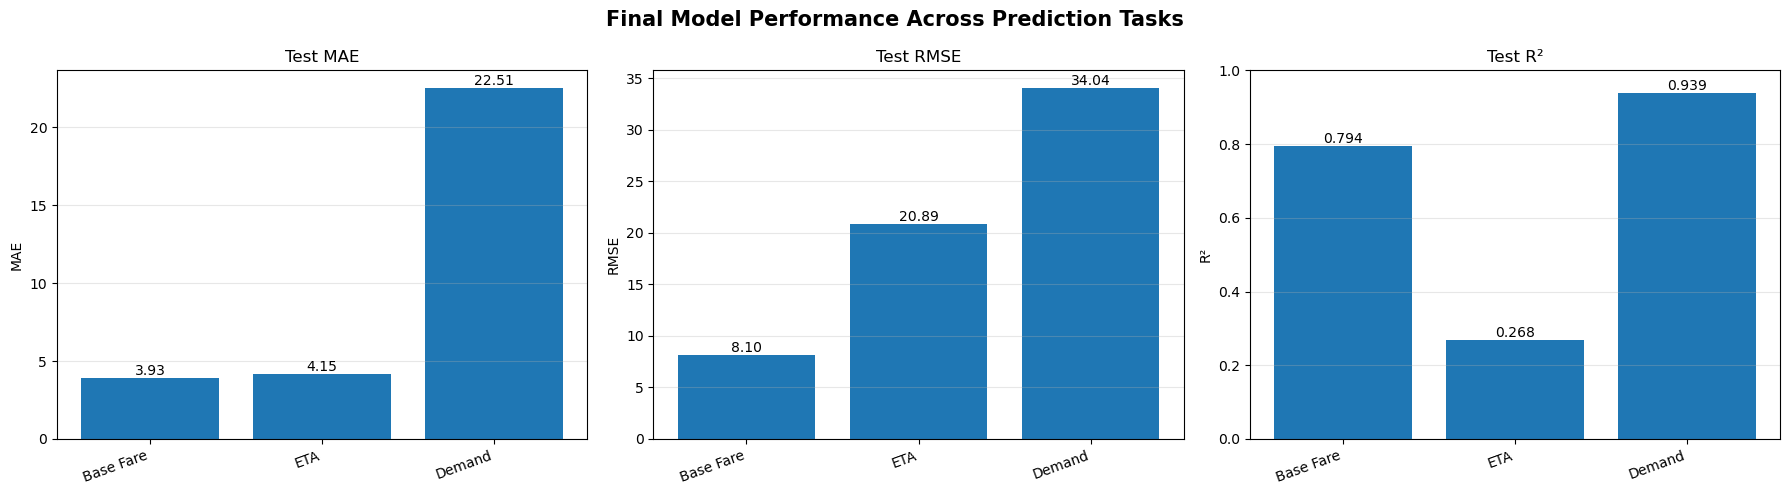

Performance figure saved to: C:\Users\arudk\Downloads\UrbanFlow_AI\reports\figures\three_task_model_performance.png


In [29]:
# Three-task model performance visualization
# Each task is shown separately because MAE/RMSE use different units across tasks.

import matplotlib.pyplot as plt
import numpy as np

results = pd.read_csv(OUTPUT_DIR / "final_model_results.csv")

# Use final test metrics
tasks = results["task"].tolist()
mae = results["test_mae"].tolist()
rmse = results["test_rmse"].tolist()
r2 = results["test_r2"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. MAE
# ---------------------------------------------------------
x = np.arange(len(tasks))

axes[0].bar(x, mae)
axes[0].set_title("Test MAE")
axes[0].set_ylabel("MAE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["Base Fare", "ETA", "Demand"],
    rotation=20,
    ha="right"
)
axes[0].grid(axis="y", alpha=0.3)

for i, value in enumerate(mae):
    axes[0].text(i, value, f"{value:.2f}", ha="center", va="bottom")

# ---------------------------------------------------------
# 2. RMSE
# ---------------------------------------------------------
axes[1].bar(x, rmse)
axes[1].set_title("Test RMSE")
axes[1].set_ylabel("RMSE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    ["Base Fare", "ETA", "Demand"],
    rotation=20,
    ha="right"
)
axes[1].grid(axis="y", alpha=0.3)

for i, value in enumerate(rmse):
    axes[1].text(i, value, f"{value:.2f}", ha="center", va="bottom")

# ---------------------------------------------------------
# 3. R²
# ---------------------------------------------------------
axes[2].bar(x, r2)
axes[2].set_title("Test R²")
axes[2].set_ylabel("R²")
axes[2].set_ylim(0, 1)
axes[2].set_xticks(x)
axes[2].set_xticklabels(
    ["Base Fare", "ETA", "Demand"],
    rotation=20,
    ha="right"
)
axes[2].grid(axis="y", alpha=0.3)

for i, value in enumerate(r2):
    axes[2].text(i, value, f"{value:.3f}", ha="center", va="bottom")

fig.suptitle(
    "Final Model Performance Across Prediction Tasks",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

# Save the figure for the final report
performance_figure_path = FIGURE_DIR / "three_task_model_performance.png"
plt.savefig(performance_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Performance figure saved to: {performance_figure_path}")

### Model Performance Interpretation

The final evaluation shows different levels of predictive performance across the three tasks.

The **demand forecasting model** achieves the strongest overall fit with a test R² of **0.9394**, indicating that the temporal and lag-based features capture most of the variation in zone-level demand.

The **base-fare model** achieves a test R² of **0.7944** with a test MAE of **3.93**, demonstrating relatively strong predictive performance.

The **ETA model** achieves a test MAE of **4.15 minutes** and an R² of **0.2676**. The lower R² reflects the substantially greater variability of individual trip durations, including the long-tailed nature of travel times. Nevertheless, the MAE provides an operationally interpretable measure of typical prediction error.

## Spatial and Demand Insights

The analysis combines taxi-zone demand, origin-destination flows, and time-of-day patterns to identify the major mobility hotspots in the city.

Three complementary views are considered:

1. **Pickup hotspots** – zones generating the highest taxi demand.
2. **Origin-destination flows** – the most frequent travel relationships between zones.
3. **AM vs PM demand** – differences in spatial demand between morning and evening periods.

These results provide operational insights that can support taxi allocation, demand anticipation, and zone-level resource planning.

In [17]:
# Set project paths relative to the final notebook location
from pathlib import Path
import pandas as pd
from IPython.display import display

# The final notebook is inside UrbanFlow_AI/notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory exists: {OUTPUT_DIR.exists()}")
print(f"Figure directory exists: {FIGURE_DIR.exists()}")

# Load final spatial-analysis outputs
top_origins = pd.read_csv(OUTPUT_DIR / "top_origin_zones.csv")
top_destinations = pd.read_csv(OUTPUT_DIR / "top_destination_zones.csv")
top_od = pd.read_csv(OUTPUT_DIR / "top_20_od_flows.csv")
am_pm = pd.read_csv(OUTPUT_DIR / "am_pm_hotspot_analysis.csv")

print("\nSpatial analysis outputs loaded successfully.")
print(f"Top origin zones: {top_origins.shape}")
print(f"Top destination zones: {top_destinations.shape}")
print(f"Top OD flows: {top_od.shape}")
print(f"AM/PM hotspot analysis: {am_pm.shape}")

Project root: C:\Users\arudk\Downloads\UrbanFlow_AI
Output directory exists: True
Figure directory exists: True

Spatial analysis outputs loaded successfully.
Top origin zones: (15, 3)
Top destination zones: (15, 3)
Top OD flows: (20, 5)
AM/PM hotspot analysis: (262, 8)


## Business Implications

The modelling and spatial analysis provide several practical insights for urban taxi operations.

### 1. Dynamic taxi allocation
Demand is concentrated in a relatively small number of high-volume zones. Taxi operators can use the demand forecasts to reposition vehicles toward expected high-demand areas before demand peaks.

### 2. Peak-period resource planning
The AM/PM analysis shows substantially stronger PM demand across the leading hotspots. This suggests that additional taxi availability should be prioritized during evening periods, particularly around major Manhattan activity centres and airport zones.

### 3. Short-term demand anticipation
The 24–72 hour forecasting model provides an operational planning signal. A test R² of **0.9394** indicates that the model captures most of the variation in zone-level hourly demand.

### 4. Fare estimation
The fare prediction model achieves a test MAE of approximately **3.93 fare units**, providing a useful estimate of expected base fare from the available trip attributes.

### 5. Travel-time planning
The ETA model achieves a test MAE of approximately **4.15 minutes**. Although the lower R² reflects the difficulty of predicting highly variable trip durations, the MAE provides an interpretable estimate of typical prediction error.

### Operational value

Together, these components can support:

- proactive taxi positioning,
- peak-period fleet planning,
- zone-level demand monitoring,
- expected fare estimation,
- estimated trip-duration planning,
- identification of dominant travel corridors.

## Proposed System Architecture

The proposed Urban Flow Analytics system follows a pipeline architecture:

**Raw Taxi Data + Zone Data**  
↓  
**Data Quality Validation**  
↓  
**Cleaning & Quality Flagging**  
↓  
**Feature Engineering**  
↓  
**Three Predictive Pipelines**

- **Fare Prediction**
- **ETA Prediction**
- **Demand Forecasting**

Alongside the predictive pipelines:

**Zone Mapping → Hotspot Analysis → AM/PM Analysis → OD Flow Analysis**

The outputs are combined into an operational analytics layer containing predictions, demand forecasts, hotspot rankings, travel-flow insights, and model evaluation metrics.

### Deployment Concept

In a production environment, new taxi records would enter the data-quality and feature-engineering pipeline before being passed to the appropriate trained model. Demand forecasting would operate on a scheduled basis using the latest historical zone-level demand observations.

The trained models are stored as serialized `.pkl` artifacts so that the modelling pipeline can be reproduced without retraining from the full raw dataset.

## Limitations and Future Improvements

Several limitations should be considered when interpreting the results.

### Data-quality limitations

The raw dataset contains multiple anomaly types, including negative durations, zero-duration trips, zero distances, zero passenger counts, unrealistic speeds, and negative monetary values. These observations were retained where appropriate for auditability but excluded from specific modelling tasks when they could invalidate the target or derived variables.

### ETA prediction

Trip duration has substantial variability and a long right tail. Consequently, the ETA model achieves a considerably lower R² than the fare and demand models. Future work could investigate additional temporal, spatial, traffic, weather, and route-level features.

### Fare prediction

The benchmark fare model uses the trip attributes available in the dataset, including `distance_miles`. For a strict production implementation where the prediction must occur before the trip begins, observed distance should be replaced with a pre-trip route-distance estimate derived from the origin and destination.

### Demand forecasting

The forecasting model focuses on the top taxi zones and uses historical temporal patterns. Future versions could incorporate weather, holidays, special events, traffic conditions, and broader spatial dependencies.

### Spatial analysis

The hotspot and OD analyses are based on aggregated zone-level flows. Future work could incorporate geographic coordinates and interactive mapping to provide more detailed spatial visualization.

### Future development

Potential improvements include:

- gradient-boosting libraries such as LightGBM or XGBoost where the deployment environment supports them,
- hyperparameter optimization with broader search spaces,
- probabilistic prediction intervals,
- external contextual variables,
- real-time streaming data,
- interactive operational dashboards.

## Conclusion

This project developed an end-to-end urban taxi analytics pipeline covering data quality assessment, fare prediction, ETA prediction, demand forecasting, hotspot identification, and origin-destination analysis.

The final models achieved:

- **Base Fare:** test MAE **3.93**, R² **0.794**
- **ETA:** test MAE **4.15 minutes**, R² **0.268**
- **Demand:** test MAE **22.51 trips**, R² **0.939**

The demand forecasting model produced the strongest overall predictive performance, while the spatial analysis revealed concentrated demand around major Manhattan activity zones and substantially stronger PM activity across the leading hotspots.

Overall, the solution demonstrates how large-scale taxi trip data can be transformed into predictive and operational insights for **fleet allocation, demand anticipation, fare estimation, travel-time planning, and urban mobility management**.

## Final Submission Readiness Check

The project contains the main analytical outputs required for the Urban Flow Analytics challenge:

- Data-quality assessment and quantified anomaly rates
- Fare prediction model
- ETA prediction model
- 24–72 hour demand forecasting
- Taxi-zone hotspot analysis
- AM vs PM comparison
- Origin-destination flow analysis
- Model validation and test metrics
- Serialized trained model artifacts
- Supporting CSV outputs and figures

The final notebook consolidates the principal findings and model results into a single reproducible project narrative.

In [24]:
# Final project artifact validation
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

required_files = {
    "Final model results": PROJECT_ROOT / "outputs" / "final_model_results.csv",
    "Data quality summary": PROJECT_ROOT / "outputs" / "data_quality_summary.csv",
    "Fare model": PROJECT_ROOT / "models" / "fare" / "base_fare_model.pkl",
    "ETA model": PROJECT_ROOT / "models" / "eta" / "eta_model.pkl",
    "ETA metadata": PROJECT_ROOT / "models" / "eta" / "eta_model_metadata.pkl",
    "Demand model": PROJECT_ROOT / "models" / "demand" / "top_zone_demand_model.pkl",
    "24-hour forecast": PROJECT_ROOT / "outputs" / "demand_forecast_24h.csv",
    "72-hour forecast": PROJECT_ROOT / "outputs" / "demand_forecast_72h.csv",
    "AM/PM analysis": PROJECT_ROOT / "outputs" / "am_pm_hotspot_analysis.csv",
    "OD flows": PROJECT_ROOT / "outputs" / "top_20_od_flows.csv",
    "Origin zones": PROJECT_ROOT / "outputs" / "top_origin_zones.csv",
    "Destination zones": PROJECT_ROOT / "outputs" / "top_destination_zones.csv",
    "72-hour forecast figure": PROJECT_ROOT / "reports" / "figures" / "72_hour_demand_forecast.png",
    "Hotspot figure": PROJECT_ROOT / "reports" / "figures" / "top_15_pickup_hotspots.png",
    "AM/PM figure": PROJECT_ROOT / "reports" / "figures" / "am_vs_pm_hotspots.png",
    "OD figure": PROJECT_ROOT / "reports" / "figures" / "top_15_od_flows.png",
}

print("FINAL PROJECT ARTIFACT CHECK")
print("=" * 60)

missing = []

for name, path in required_files.items():
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    print(f"{status:8} | {name}")
    
    if not exists:
        missing.append((name, path))

print("=" * 60)

if not missing:
    print("All required analytical artifacts are present.")
else:
    print(f"{len(missing)} artifact(s) are missing.")
    for name, path in missing:
        print(f"  - {name}: {path}")

FINAL PROJECT ARTIFACT CHECK
OK       | Final model results
OK       | Data quality summary
OK       | Fare model
OK       | ETA model
OK       | ETA metadata
OK       | Demand model
OK       | 24-hour forecast
OK       | 72-hour forecast
OK       | AM/PM analysis
OK       | OD flows
OK       | Origin zones
OK       | Destination zones
OK       | 72-hour forecast figure
OK       | Hotspot figure
OK       | AM/PM figure
OK       | OD figure
All required analytical artifacts are present.


## Final Project Status

All major analytical components have been completed and validated.

### Completed Components

- Large-scale taxi dataset audit
- Data-quality anomaly identification and quantification
- Data-quality decision framework
- Base-fare prediction
- ETA prediction
- 24-hour demand forecasting
- 72-hour demand forecasting
- Pickup hotspot analysis
- AM vs PM hotspot comparison
- Origin-destination flow analysis
- Model validation and test evaluation
- Final model performance comparison
- Business implications
- System architecture
- Limitations and future improvements
- Serialized trained model artifacts
- Supporting analytical outputs and figures

The final notebook serves as the consolidated presentation of the Urban Flow Analytics solution.

## Final Model Performance Summary

The following figure presents the three final prediction tasks using separate metric panels. This avoids directly comparing metrics with different units while providing a clear overview of predictive performance.

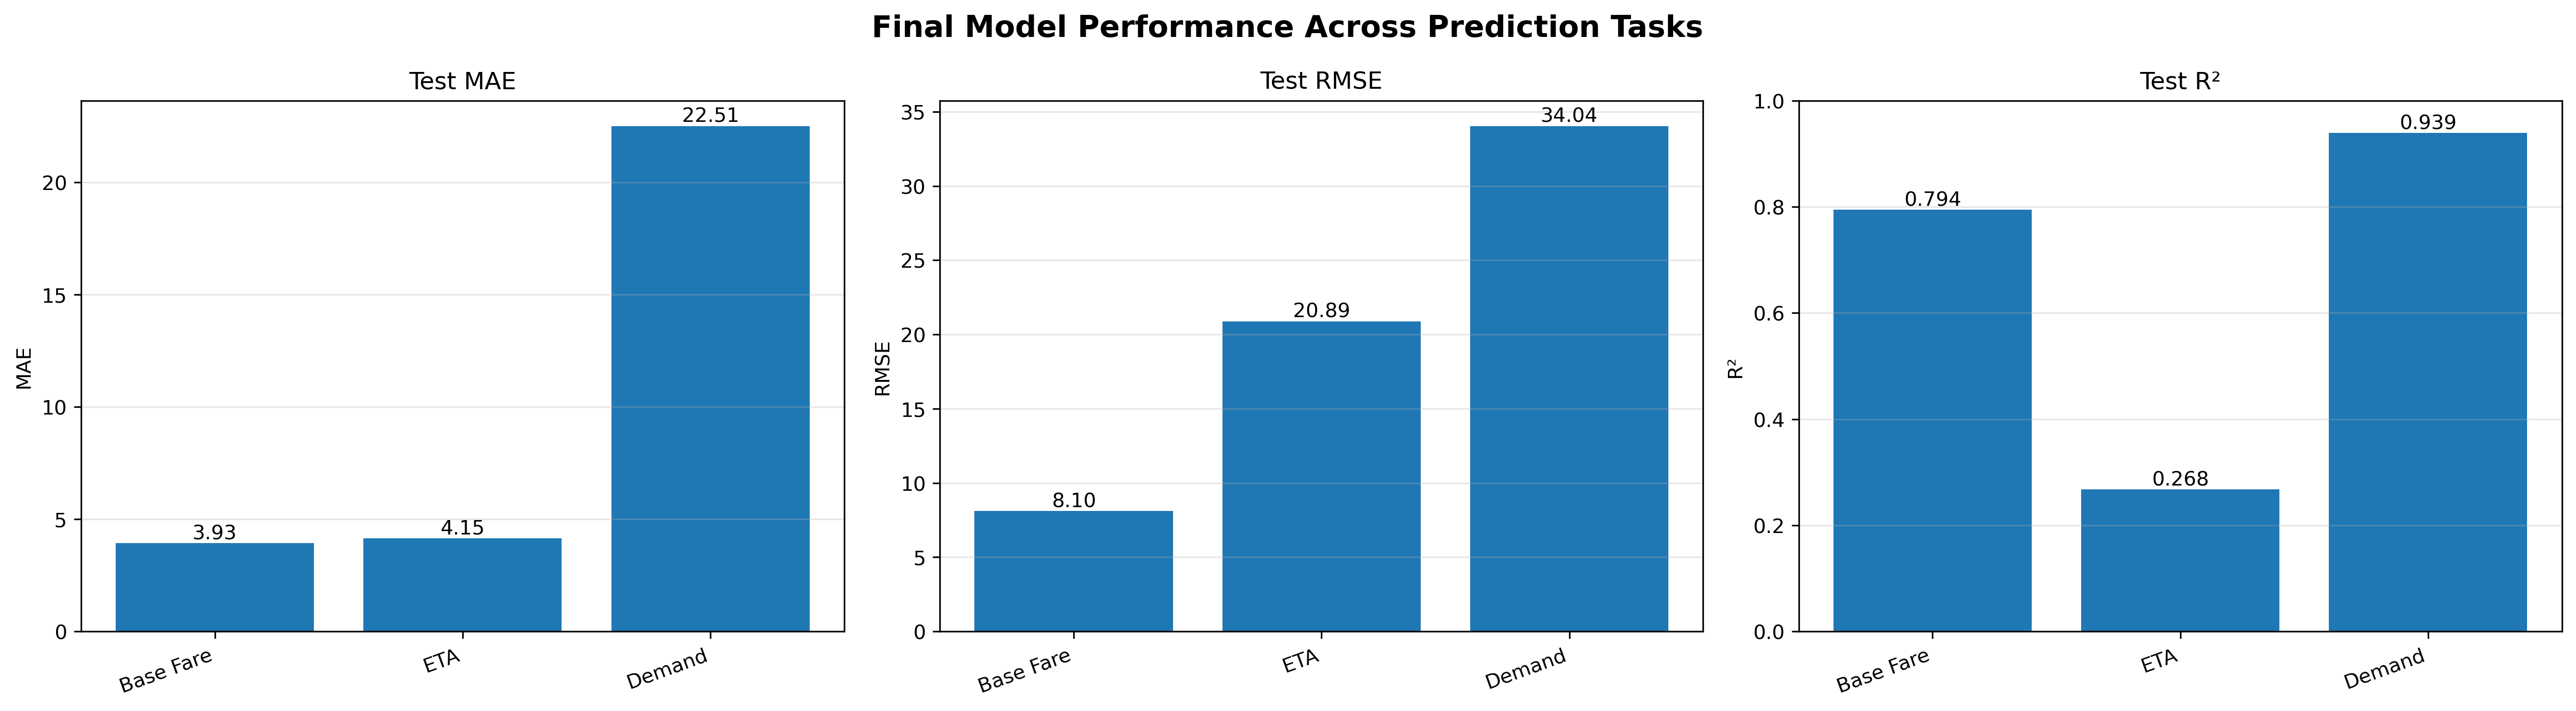

In [33]:
from IPython.display import Image, display

performance_figure_path = FIGURE_DIR / "three_task_model_performance.png"

display(Image(filename=str(performance_figure_path)))

In [35]:
# Final submission artifact validation

required_files["Three-task performance figure"] = (
    PROJECT_ROOT / "reports" / "figures" / "three_task_model_performance.png"
)

print("FINAL SUBMISSION ARTIFACT CHECK")
print("=" * 65)

missing = []

for name, path in required_files.items():
    if path.exists():
        print(f"OK       | {name}")
    else:
        print(f"MISSING  | {name}")
        missing.append((name, path))

print("=" * 65)

if not missing:
    print("SUCCESS: All final analytical artifacts are present.")
else:
    print(f"WARNING: {len(missing)} artifact(s) are missing.")
    for name, path in missing:
        print(f"  -> {name}: {path}")

FINAL SUBMISSION ARTIFACT CHECK
OK       | Final model results
OK       | Data quality summary
OK       | Fare model
OK       | ETA model
OK       | ETA metadata
OK       | Demand model
OK       | 24-hour forecast
OK       | 72-hour forecast
OK       | AM/PM analysis
OK       | OD flows
OK       | Origin zones
OK       | Destination zones
OK       | 72-hour forecast figure
OK       | Hotspot figure
OK       | AM/PM figure
OK       | OD figure
OK       | Three-task performance figure
SUCCESS: All final analytical artifacts are present.
